<a href="https://colab.research.google.com/github/servetgencimli-dotcom/DataScience/blob/main/Detect_Crop_Diseases_Using_Aerial_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('meta_deta.csv')

In [ ]:
df

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
...,...,...
21392,999068805.jpg,3
21393,999329392.jpg,3
21394,999474432.jpg,1
21395,999616605.jpg,4


In [ ]:
df.isnull().sum()

image_id    0
label       0
dtype: int64

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
image_folder = "images"

# yeni dataset folderi
base_dir = "dataset"

# split
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

splits = {
    "train": train_df,
    "valid": valid_df,
    "test": test_df
}

# class folderləri yaradiram
classes = df["label"].unique()

for split in splits:
    for cls in classes:
        os.makedirs(
            os.path.join(base_dir, split, str(cls)),
            exist_ok=True
        )

# şəkilləri köçürurem
for split_name, split_df in splits.items():

    for _, row in split_df.iterrows():

        image_name = row["image_id"]
        label = str(row["label"])

        src = os.path.join(image_folder, image_name)

        dst = os.path.join(
            base_dir,
            split_name,
            label,
            image_name
        )

        if os.path.exists(src):
            shutil.copy(src, dst)

print("Dataset hazırdır.")

Dataset hazırdır.


In [ ]:
from torchvision.datasets  import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
train_data = ImageFolder("dataset/train", transform=train_transform)
val_data = ImageFolder("dataset/valid", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 5)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:


class_counts = torch.tensor([142, 280, 309, 1668, 333], dtype=torch.float)

weights = 1.0 / class_counts
weights = weights / weights.sum()

print(weights)
criterion = nn.CrossEntropyLoss(weight=weights.to(device), label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


tensor([0.4035, 0.2046, 0.1854, 0.0344, 0.1721])


In [ ]:
for epoch in range(10):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.9938056863496958
Epoch 2, Loss: 0.7283093201990573
Epoch 3, Loss: 0.6035184497351473
Epoch 4, Loss: 0.5064204630533649
Epoch 5, Loss: 0.42342414054537064
Epoch 6, Loss: 0.3251094011773254
Epoch 7, Loss: 0.24337636912000302
Epoch 8, Loss: 0.18280420492408034
Epoch 9, Loss: 0.15759741094137103
Epoch 10, Loss: 0.13710073848288756


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print('Classification Report\n',classification_report(y_true, y_pred))
print("Confusion Matrix\n", confusion_matrix(y_true, y_pred))
print('Accuracy Score',accuracy_score(y_true, y_pred))

Classification Report
               precision    recall  f1-score   support

           0       0.52      0.60      0.56       126
           1       0.76      0.73      0.74       255
           2       0.70      0.73      0.71       262
           3       0.96      0.92      0.94      1473
           4       0.59      0.69      0.64       291

    accuracy                           0.83      2407
   macro avg       0.71      0.73      0.72      2407
weighted avg       0.84      0.83      0.84      2407

Confusion Matrix
 [[  75   13    3    4   31]
 [  20  185    8   14   28]
 [   6    7  191   24   34]
 [   6   20   54 1348   45]
 [  37   19   18   15  202]]
Accuracy Score 0.8313253012048193


c:\Users\MSI\ANAconda\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


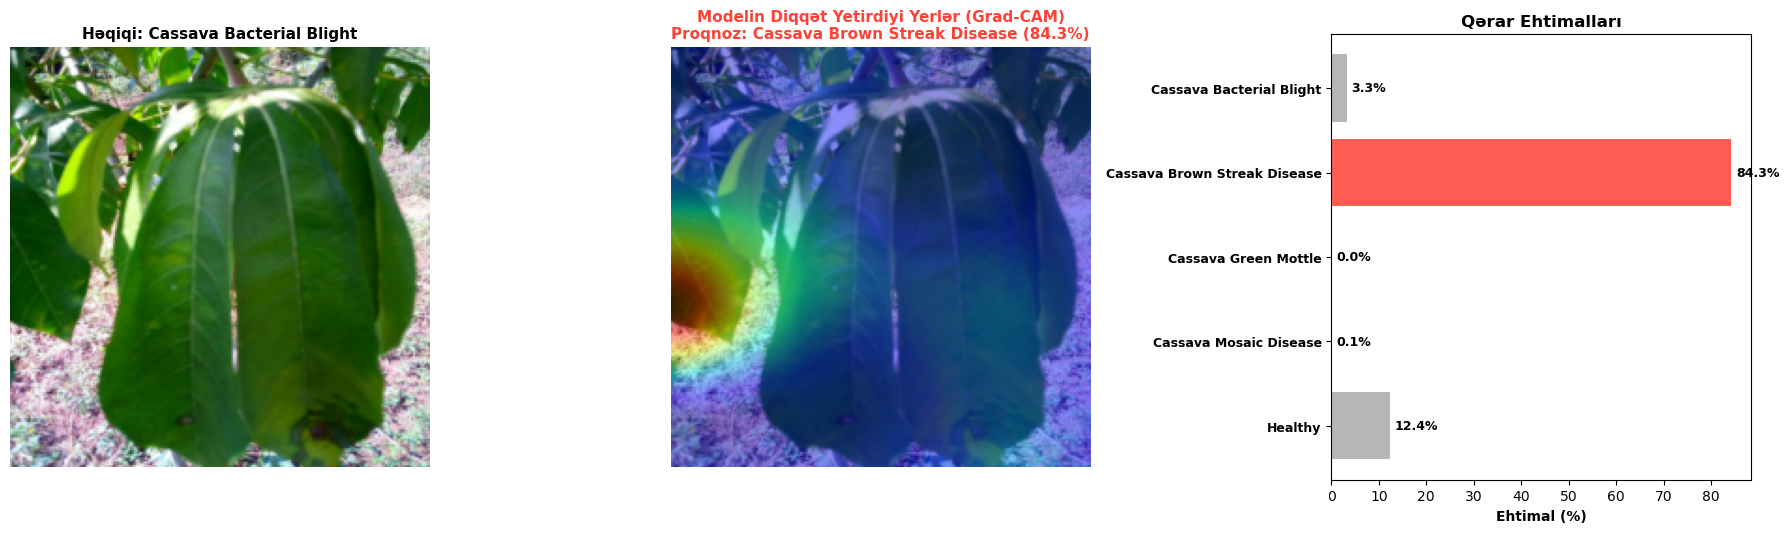

In [ ]:
# =========================================================================
# KREATIV GRAD-CAM VİZUALLAŞDIRILMASI (EXPLAINABLE AI)
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# 1. Grad-CAM Funksiyası
def get_gradcam(model, image_tensor, target_layer, class_idx=None):
    model.eval()
    feature_maps = []
    gradients = []

    def forward_hook(module, input, output):
        feature_maps.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_backward_hook(backward_hook)

    output = model(image_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, class_idx].backward()

    h1.remove()
    h2.remove()

    grads = gradients[0][0]
    fmaps = feature_maps[0][0]

    weights = grads.mean(dim=(1, 2), keepdim=True)
    cam = (weights * fmaps).sum(dim=0)
    cam = F.relu(cam)

    cam -= cam.min()
    cam /= (cam.max() + 1e-8)

    return cam.detach().cpu().numpy(), output

# 2. Validation Dataloader-dən Bir Şəkil Analiz Edirik (val_loader ilə)
model.eval()
images, labels = next(iter(val_loader)) # <--- Bura düzəldildi: val_loader
image = images[0:1].to(device)
label = labels[0].item()

# EfficientNet-B0 modelinin son konvolutiv qatını hədəf seçirik
target_layer = model.features[-1]
cam, output = get_gradcam(model, image, target_layer)

# Proqnoz ehtimallarını hesablayırıq
probabilities = F.softmax(output, dim=1).detach().cpu().numpy()[0]
pred_class = np.argmax(probabilities)

# Yarpaq şəklini normalizasiyadan geri qaytarırıq (RGB göstərmək üçün)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = image[0].cpu().numpy().transpose(1, 2, 0)
img_np = np.clip(img_np * std + mean, 0, 1)

# Rəngli istilik xəritəsini yarpaq şəklinin ölçüsünə böyüdürük
cam_resized = zoom(cam, (img_np.shape[0] / cam.shape[0], img_np.shape[1] / cam.shape[1]))

# Bitki Xəstəliklərinin Adları
class_names = [
    "Cassava Bacterial Blight (CBB)",
    "Cassava Brown Streak Disease (CBSD)",
    "Cassava Green Mottle (CGM)",
    "Cassava Mosaic Disease (CMD)",
    "Healthy"
]

# 3. Möhtəşəm Vizuallaşdırma Paneli (3 Subplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# A) Həqiqi Şəkil
axes[0].imshow(img_np)
axes[0].set_title(f"Həqiqi: {class_names[label].split(' (')[0]}", fontsize=11, fontweight='bold')
axes[0].axis('off')

# B) Grad-CAM İstilik Overlay Xəritəsi (Model haraya baxır?)
axes[1].imshow(img_np)
axes[1].imshow(cam_resized, cmap='jet', alpha=0.45)
axes[1].set_title(f"Modelin Diqqət Yetirdiyi Yerlər (Grad-CAM)\nProqnoz: {class_names[pred_class].split(' (')[0]} ({probabilities[pred_class]*100:.1f}%)", fontsize=11, fontweight='bold', color='#FF4136')
axes[1].axis('off')

# C) Bütün Siniflərin Ehtimal Faizləri
y_pos = np.arange(len(class_names))
colors = ['#FF4136' if i == pred_class else '#aaaaaa' for i in range(len(class_names))]
if pred_class == 4:
    colors[pred_class] = '#2ECC40' # Sağlam yarpaq üçün yaşıl rəng

bars = axes[2].barh(y_pos, probabilities * 100, align='center', color=colors, alpha=0.85)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels([name.split(' (')[0] for name in class_names], fontsize=9, fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_xlabel('Ehtimal (%)', fontsize=10, fontweight='bold')
axes[2].set_title('Qərar Ehtimalları', fontsize=12, fontweight='bold')

# Faizləri qrafikin üzərində göstəririk
for bar in bars:
    width = bar.get_width()
    axes[2].text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
                 ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


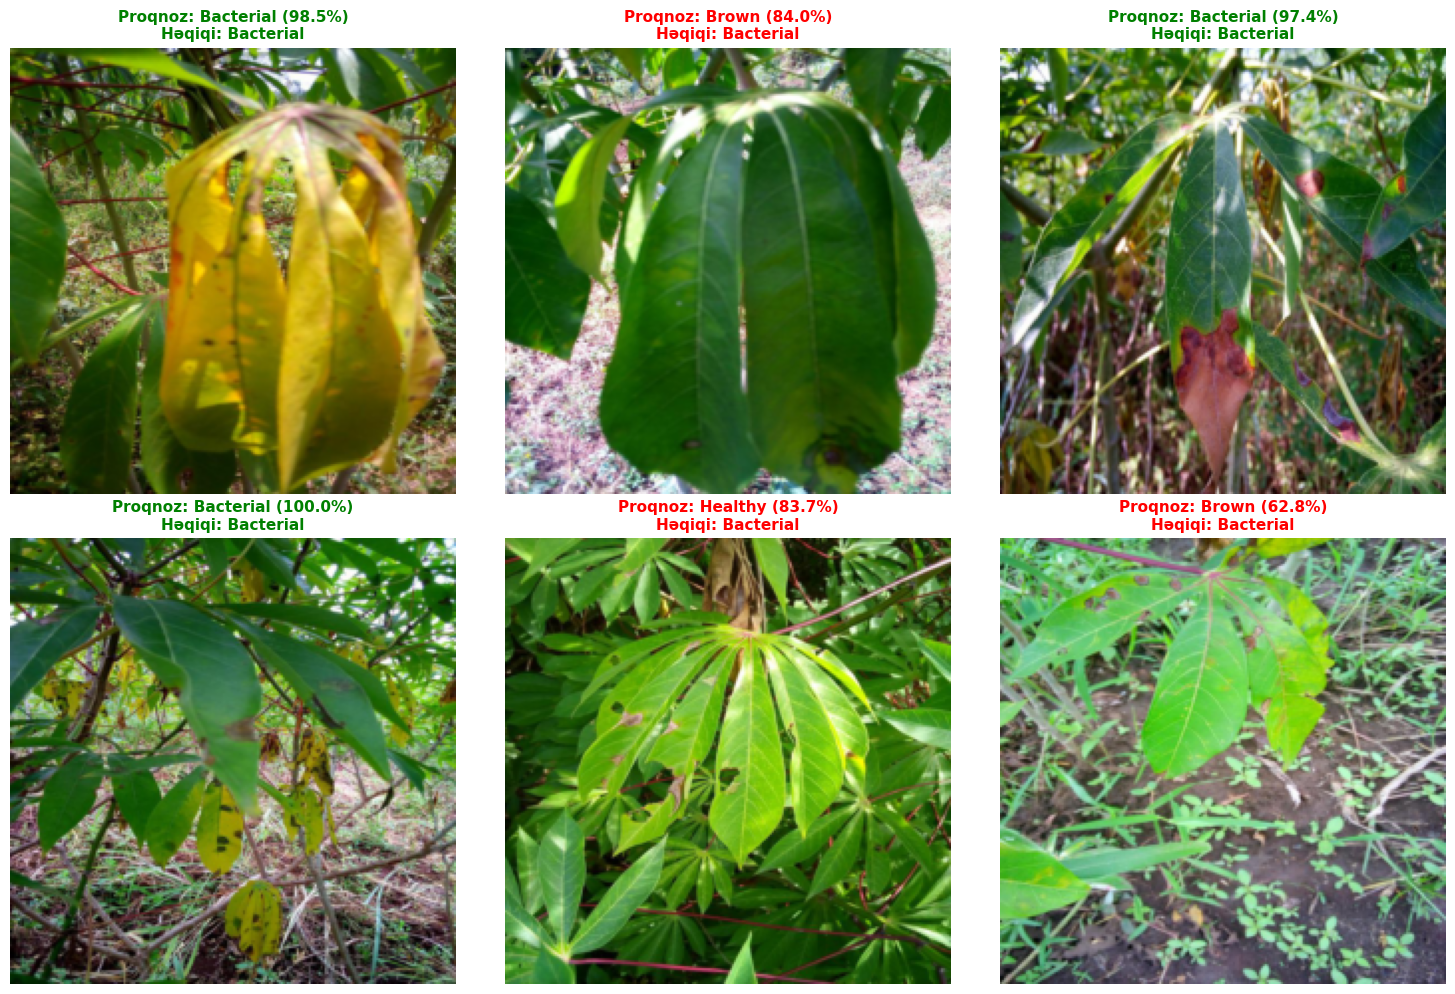

In [ ]:
# =========================================================================
# TEST QALEREYASI: MODELİN PROQNOZLARININ GÖZƏL VİZUALLAŞDIRILMASI
# =========================================================================
import random
import torch.nn.functional as F

model.eval()
images, labels = next(iter(val_loader))
images_dev = images.to(device)

with torch.no_grad():
    outputs = model(images_dev)
    probabilities = F.softmax(outputs, dim=1)
    preds = torch.argmax(probabilities, dim=1)

# Təsadüfi 6 şəkil seçirik
indices = random.sample(range(len(images)), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
class_names = ["Bacterial Blight", "Brown Streak", "Green Mottle", "Mosaic Disease", "Healthy"]

for i, idx in enumerate(indices):
    # Şəkli vizuallaşdırma üçün normalizasiyadan çıxarırıq
    img_np = images[idx].numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * std + mean, 0, 1)

    true_label = labels[idx].item()
    pred_label = preds[idx].item()
    prob = probabilities[idx][pred_label].item() * 100

    # Düzgün proqnozu yaşıl, səhvi isə qırmızı rənglə işarələyirik
    color = "green" if true_label == pred_label else "red"
    title_text = f"Proqnoz: {class_names[pred_label].split(' ')[0]} ({prob:.1f}%)\nHəqiqi: {class_names[true_label].split(' ')[0]}"

    axes[i].imshow(img_np)
    axes[i].set_title(title_text, fontsize=11, fontweight="bold", color=color)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


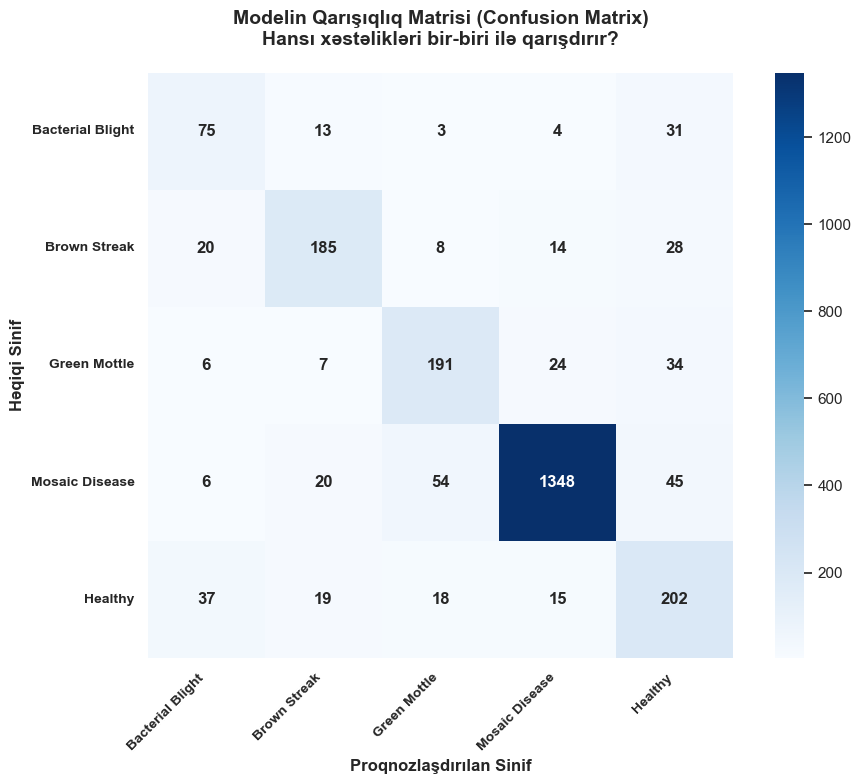

In [ ]:
# =========================================================================
# VİZUAL QARIŞIQLIQ MATRİSİ (CONFUSION MATRIX HEATMAP)
# =========================================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Bütün validation proqnozlarını yığırıq
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

# 2. Qarışıqlıq matrisini hesablayırıq
cm = confusion_matrix(y_true, y_pred)
class_names = ["Bacterial Blight", "Brown Streak", "Green Mottle", "Mosaic Disease", "Healthy"]

# 3. Möhtəşəm Rəngli Heatmap Qrafiki
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    square=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Modelin Qarışıqlıq Matrisi (Confusion Matrix)\nHansı xəstəlikləri bir-biri ilə qarışdırır?", fontsize=14, fontweight="bold", pad=20)
plt.ylabel("Həqiqi Sinif", fontsize=12, fontweight="bold")
plt.xlabel("Proqnozlaşdırılan Sinif", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight="bold")
plt.yticks(rotation=0, fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
